In [264]:
# Importation des packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [142]:
# Importation des données
df = pd.read_excel('data/data.xlsx', header=1)

In [149]:
df.head(1)

,Date operation,LIBELLE,ACT,IND,INDLIB,PORTEF,Montant,Duree,PRIOD,Taux %,NBRE ECH,SEX,VALEURGARANT,AGENCELIB,IMPAYE,NBIMP,MNTREMB,DATENAIS,ETATCIVIL,DEPNAISLIB,SECT_ACTIV
18,20-APR-17,CRDT LT- MOURABAHA FADES DD,DD,23.0,"Hôtel, Café, Restaurant, Spectacle",DD,16000000.0,96,T,8.0,32,Female,26000000.0,NOUAKCHOTT 1 - SIEGE,0.0,0,788565.21,1966-07-14 00:00:00,Married,Toute la Mauritanie,AUTRES SOCIETES


In [150]:
# Renommer les variables 
df = df.rename(columns={
    'Date operation': 'DATE_OPERATION', 
    'Montant': 'MONTANT', 
    'Duree': 'DUREE', 
    'PRIOD': 'PERIODE',
    'Taux %': 'TAUX_INT',
    'NBRE ECH': 'NB_ECH',
    'SEX': 'SEXE'})

In [151]:
pd.set_option('display.max_columns', None)

In [153]:
df = df[(df['VALEURGARANT'].notna()) & (df['PORTEF'] != 'FSE') & (df['SEXE'].notna())]

In [156]:
df.shape

(927, 21)

In [157]:
df['INDLIB'].unique()

<StringArray>
[                      'Hôtel, Café, Restaurant, Spectacle',
                                            'Autre Service',
                                       'Industrie de Pêche',
                                         'Commerce Général',
                                                        nan,
                              'Bâtiment et Travaux Publics',
                              'Élevage, Production Animale',
                                                   'Divers',
                                      'Production Agricole',
                                               'Transports',
                                    'Industrie Alimentaire',
    'Industrie Métaux, Construction Mécanique & Électrique',
                    'Commerce Véhicules & Pièces Détachées',
                   'Industrie Textile, Cuir et Habillement',
                                           'Autre Commerce',
                          'Commerce Spécialisé Alimentaire',
 'Commerce

In [159]:
corrections = {
    'H�tel, Caf�, Retaurant, Spectacl': 'Hôtel, Café, Restaurant, Spectacle',
    'Industrie de P�che': 'Industrie de Pêche',
    'Commerce G�n�ral': 'Commerce Général',
    'B�timent et Travaux Publics': 'Bâtiment et Travaux Publics',
    'Elevage, Production Animale': 'Élevage, Production Animale',
    'Indus. M�taux, Const M�ca & El�c': 'Industrie Métaux, Construction Mécanique & Électrique',
    'Commerce V�hicules & Pi�ces D�t': 'Commerce Véhicules & Pièces Détachées',
    'Indus. Text Cuir et Habillement': 'Industrie Textile, Cuir et Habillement',
    'Commerce Sp�cialis� Alimentaire': 'Commerce Spécialisé Alimentaire',
    'Commerce Mat.1�re, Const, Quinca': 'Commerce Matières Premières, Construction, Quincaillerie',
    'Industrie Materiaux Construction': 'Industrie Matériaux Construction',
    'Transit Manut, Auxiliare Transp': 'Transit, Manutention, Auxiliaire Transport',
    'Production et Distrib Eau/El�ct': 'Production et Distribution Eau/Électricité'
}

df['INDLIB'] = df['INDLIB'].replace(corrections)

In [160]:
df.to_excel('data/working_dataset.xlsx', index=False)

In [ ]:
# Importation des données 
df = pd.read_excel('data/working_dataset.xlsx')

In [164]:
df.shape

(927, 21)

In [101]:
df['Date operation'] = pd.to_datetime(df['Date operation'])

C:\Users\delli7\AppData\Local\Temp\ipykernel_18120\983195359.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date operation'] = pd.to_datetime(df['Date operation'])


In [89]:
# Insert after the first column (position 1)

df.insert(1, 'ANNEE_OPERATION', df['Date operation'].dt.year)
df.insert(2, 'MOIS_OPERATION', df['Date operation'].dt.month)
df.insert(3, 'ANCIENNETE', (pd.Timestamp.today() - df['Date operation']).dt.days)

# Netoyage des données

### DATE_OPERATION

In [174]:
df['DATE_OPERATION'] = pd.to_datetime(
    df['DATE_OPERATION'],
    format='%d-%b-%y',
    errors='coerce'
)

### INDLIB & IND

In [224]:
round(df['INDLIB'].value_counts(normalize=True) * 100, 2)

INDLIB
Commerce Général                                            64.94
Autre Service                                                8.63
Autre Commerce                                               7.01
Bâtiment et Travaux Publics                                  2.80
Industrie de Pêche                                           2.37
Divers                                                       2.37
Non renseigné                                                2.27
Hôtel, Café, Restaurant, Spectacle                           2.05
Production Agricole                                          1.73
Élevage, Production Animale                                  0.97
Industrie Textile, Cuir et Habillement                       0.97
Transports                                                   0.86
Commerce Véhicules & Pièces Détachées                        0.86
Industrie Alimentaire                                        0.43
Commerce Spécialisé Alimentaire                              0.43
Ind

In [225]:
# Pourcentage des valeurs manquantes
print(f"Valeurs manquantes: {df['INDLIB'].isnull().sum()}/{df.shape[0]} ({round((df['INDLIB'].isnull().sum() / df.shape[0]) * 100, 2)}%)")

Valeurs manquantes: 0/927 (0.0%)


In [226]:
# Remplacer les valeurs manquantes 
df['IND'] = df['IND'].fillna(0)
df['INDLIB'] = df['INDLIB'].fillna('Non renseigné')

### MONTANT

<Axes: >

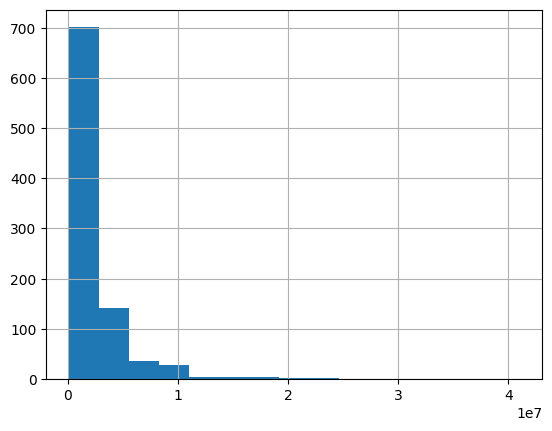

In [233]:
df['MONTANT'].hist(bins=15)

In [234]:
(df['MONTANT'] <= 0).sum()

np.int64(0)

### DATENAIS

In [271]:
def clean_birth_date(x):
    if pd.isna(x):
        return pd.NaT

    # If already datetime
    if isinstance(x, (pd.Timestamp, datetime)):
        date = pd.to_datetime(x)

    # If Excel serial number
    elif isinstance(x, (int, float)):
        date = pd.to_datetime(x, origin='1899-12-30', unit='D')

    # If text like 25-MAY-72
    else:
        date = pd.to_datetime(x, format='%d-%b-%y', errors='coerce')

    # Correct future birth dates caused by 2-digit year problem
    if pd.notna(date) and date.year > datetime.today().year:
        date = date - pd.DateOffset(years=100)

    return date

df['DATENAIS'] = df['DATENAIS'].apply(clean_birth_date)

In [273]:
df['DATENAIS']

0     1966-07-14
1     1972-05-25
2     1966-12-30
3     1954-12-31
4     1960-02-17
         ...    
922   1967-12-30
923   1967-01-01
924   1968-12-30
925   1970-12-31
926   1969-11-10
Name: DATENAIS, Length: 927, dtype: datetime64[us]

# Analyse Descriptive

### PORTEF

In [207]:
df['PORTEF'].isnull().mean() * 100

np.float64(0.0)

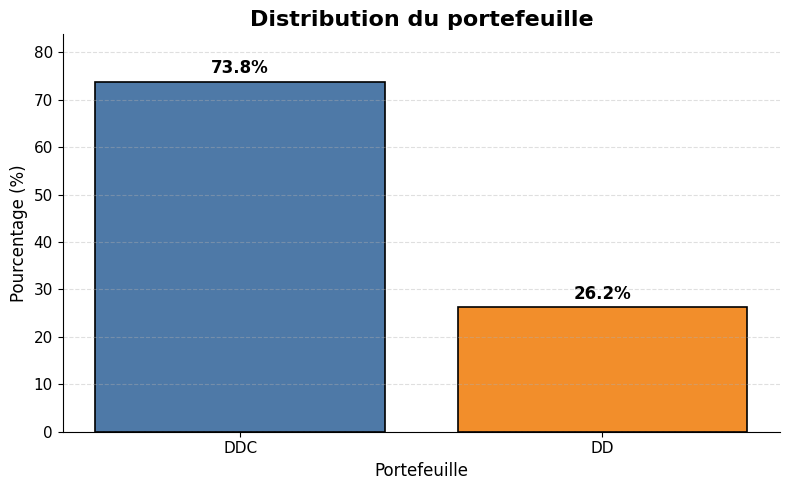

In [113]:
# Calcul des pourcentages
data = df['PORTEF'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

# Couleurs personnalisées
colors = ['#4E79A7', '#F28E2B']  # bleu + orange professionnel

# Création du graphique
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1.2
)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Personnalisation
plt.title('Distribution du portefeuille', fontsize=16, fontweight='bold')
plt.xlabel('Portefeuille', fontsize=12)
plt.ylabel('Pourcentage (%)', fontsize=12)

plt.ylim(0, data.max() + 10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

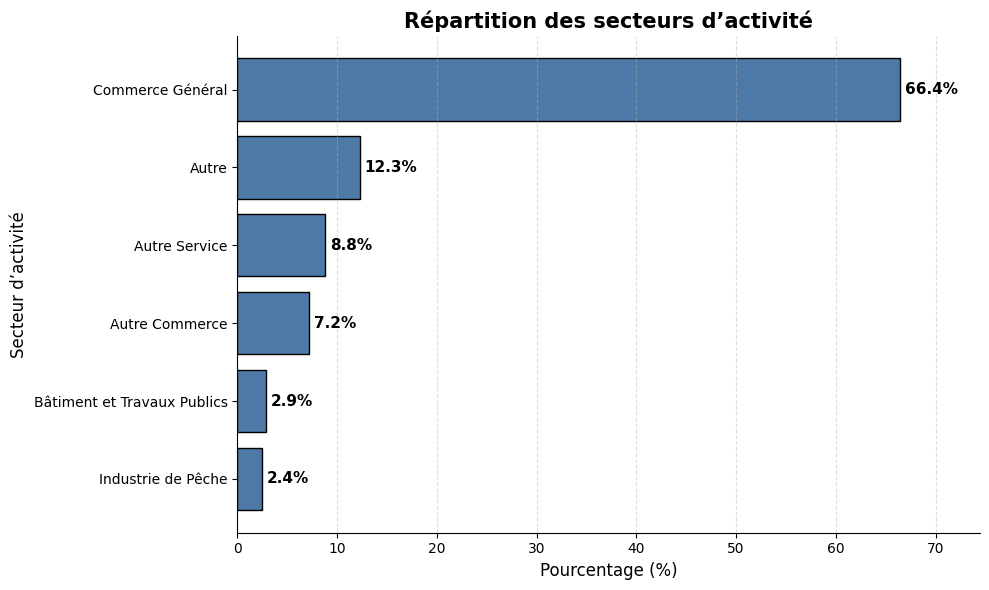

In [116]:
# Fréquences en pourcentage
data = df['INDLIB'].value_counts(normalize=True).mul(100)

# Top 5 modalités
top5 = data.head(5)

# Regrouper le reste dans "Autre"
autre = pd.Series({'Autre': data.iloc[5:].sum()})

# Données finales
data_plot = pd.concat([top5, autre])

# Trier pour que la plus grande barre soit en haut
data_plot = data_plot.sort_values(ascending=True)

# Graphique horizontal
plt.figure(figsize=(10, 6))

bars = plt.barh(
    data_plot.index,
    data_plot.values,
    color='#4E79A7',
    edgecolor='black',
    linewidth=1
)

# Ajouter les pourcentages au bout des barres
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Répartition des secteurs d’activité', fontsize=15, fontweight='bold')
plt.xlabel('Pourcentage (%)', fontsize=12)
plt.ylabel('Secteur d’activité', fontsize=12)

plt.xlim(0, data_plot.max() + 8)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Montant

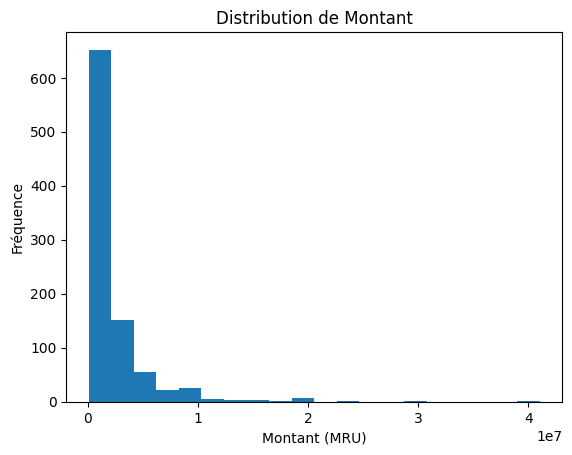

In [117]:
plt.hist(df['Montant'], bins=20)
plt.xlabel('Montant (MRU)')
plt.ylabel('Fréquence')
plt.title('Distribution de Montant')
plt.show()

<Axes: >

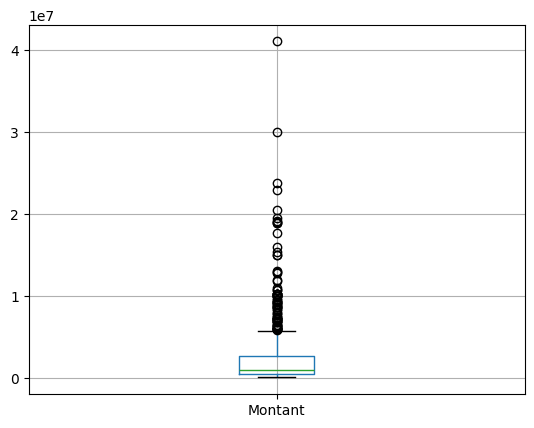

In [110]:
df.boxplot(column='Montant')

### Duree

In [111]:
df['Duree'].describe()

count    927.000000
mean      50.933118
std        9.438207
min        8.000000
25%       48.000000
50%       48.000000
75%       60.000000
max      144.000000
Name: Duree, dtype: float64

Text(0.5, 1.0, 'Distribution de durée')

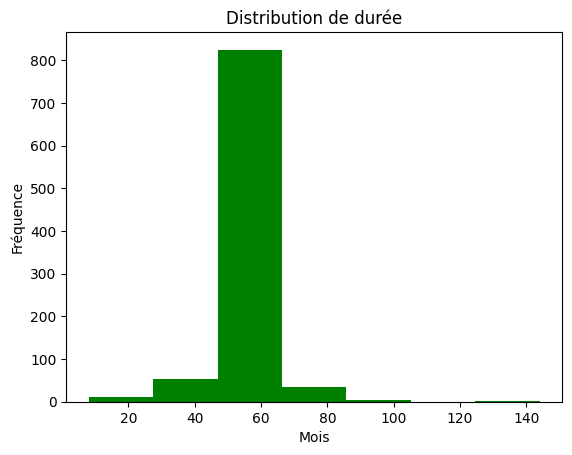

In [112]:
plt.hist(df['Duree'], bins=7, color='green')
plt.xlabel('Mois')
plt.ylabel('Fréquence')
plt.title('Distribution de durée')

### PERIODE

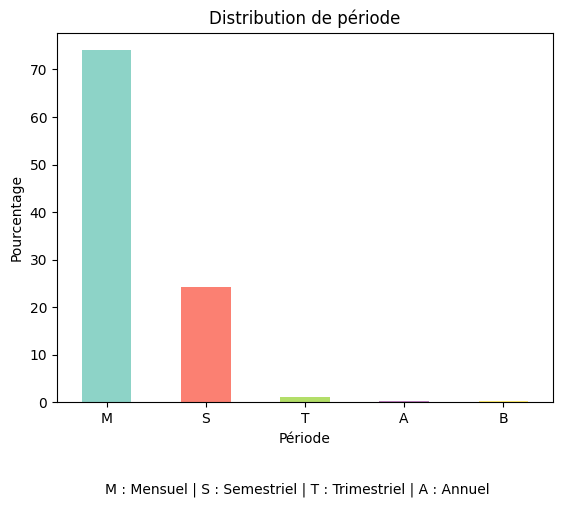

In [115]:
data = df['PRIOD'].value_counts(normalize=True).mul(100)

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

data.plot(kind='bar', color=colors)

plt.xticks(rotation=0)
plt.xlabel('Période')
plt.ylabel('Pourcentage')
plt.title('Distribution de période')

plt.figtext(
    0.5, -0.08,
    "M : Mensuel | S : Semestriel | T : Trimestriel | A : Annuel",
    ha='center',
    fontsize=10
)

plt.show()

### Taux %

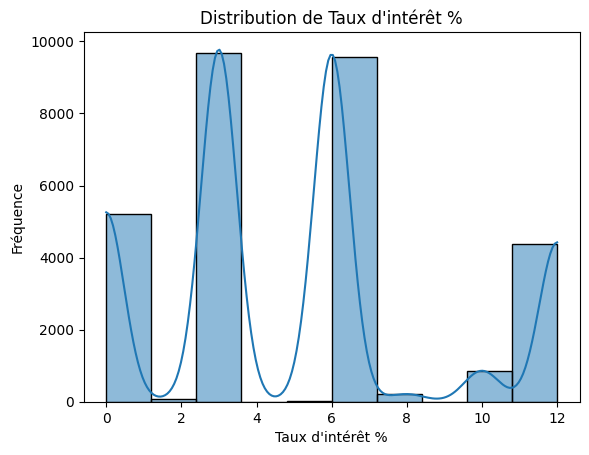

In [7]:
sns.histplot(df['Taux %'], bins=10, kde=True)

plt.xlabel("Taux d'intérêt %")
plt.ylabel('Fréquence')
plt.title("Distribution de Taux d'intérêt %")
plt.show()

### NBRE ECH

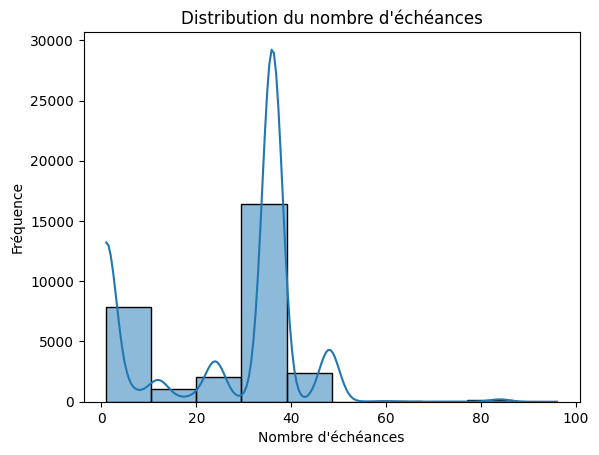

In [8]:
sns.histplot(df['NBRE ECH'], bins=10, kde=True)

plt.xlabel("Nombre d'échéances")
plt.ylabel('Fréquence')
plt.title("Distribution du nombre d'échéances")
plt.show()

### VALEURGARANT

In [16]:
print(float(round(df['VALEURGARANT'].isnull().mean() * 100, 2)),"%")

96.9 %


### AGENCELIB

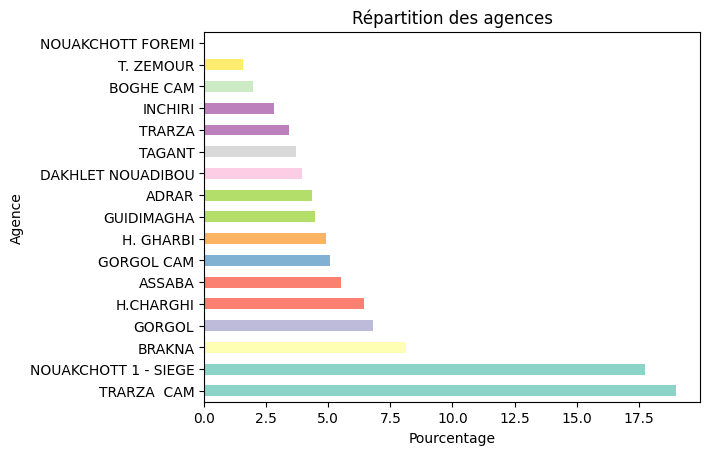

In [17]:
data = df['AGENCELIB'].value_counts(normalize=True).mul(100)

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

data.plot(kind='barh', color=colors)

plt.xlabel('Pourcentage')
plt.ylabel('Agence')
plt.title('Répartition des agences')

plt.show()

### IMPAYE

In [131]:
(df['IMPAYE'] == 0).sum() / (df['IMPAYE'].count())

np.float64(0.46991967469919677)

<Axes: xlabel='NBIMP', ylabel='Count'>

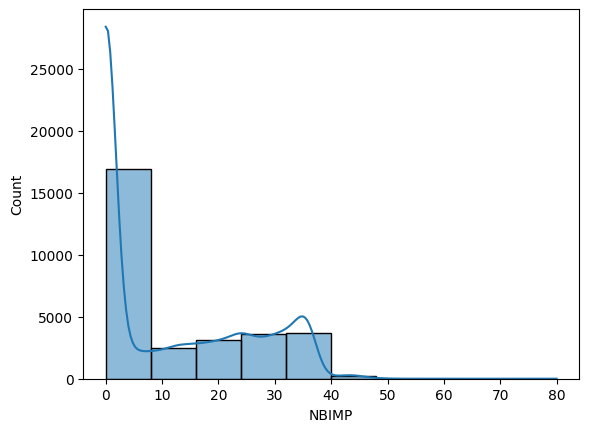

In [135]:
sns.histplot(df['NBIMP'], bins=10, kde=True)

### MNTREMB

<Axes: xlabel='MNTREMB', ylabel='Count'>

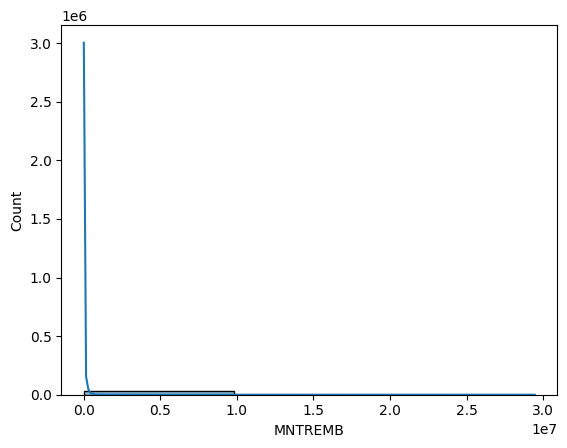

In [138]:
sns.histplot(df['MNTREMB'], bins=3, kde=True)

### SEX

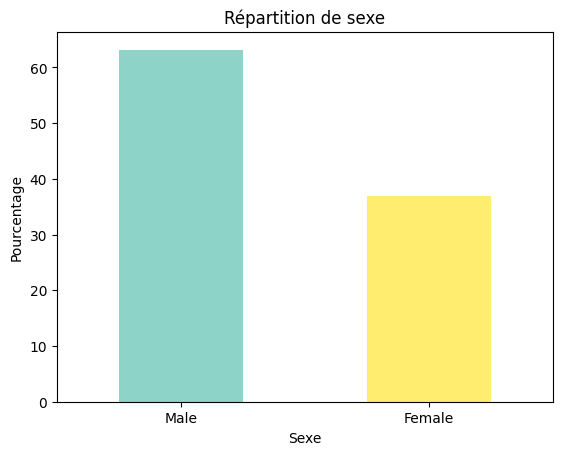

In [175]:
data = df['SEX'].value_counts(normalize=True).mul(100)

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

data.plot(kind='bar', color=colors)

plt.xticks(rotation=0)
plt.xlabel('Sexe')
plt.ylabel('Pourcentage')
plt.title('Répartition de sexe')
plt.show()

### DATENAIS

In [ ]:
df['DATENAIS'] = pd.to_datetime(
    df['DATENAIS'],
    errors='coerce',
    dayfirst=True
)

# Position of DATENAIS
pos = df.columns.get_loc('DATENAIS')

# Create and insert new variables directly after DATENAIS
df.insert(pos + 1, 'annee_nais', df['DATENAIS'].dt.year)
df.insert(pos + 2, 'mois_nais', df['DATENAIS'].dt.month)


In [181]:
condition = (df['annee_nais'] >= 1930) & (df['annee_nais'] <= 2010)

df.loc[~condition, ['DATENAIS', 'annee_nais', 'mois_nais']] = pd.NA

### ETAT CIVIL

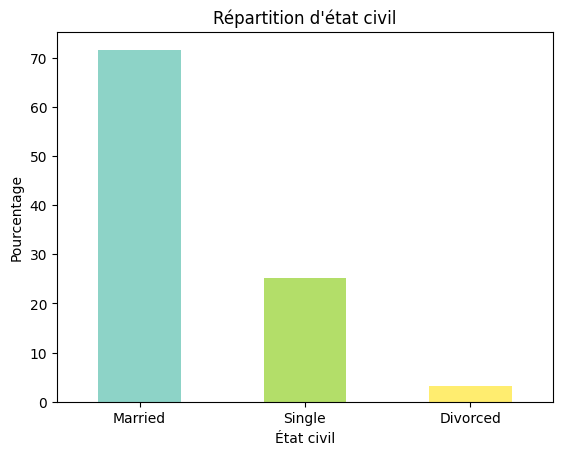

In [195]:
data = df['ETATCIVIL'].value_counts(normalize=True).mul(100)

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

data.plot(kind='bar', color=colors)

plt.xticks(rotation=0)
plt.xlabel('État civil')
plt.ylabel('Pourcentage')
plt.title("Répartition d'état civil")
plt.show()

### DEPNAISLIB

In [204]:
df[df['DEPNAISLIB'] == 'Toute la Mauritanie'].shape[0] / df.shape[0]

0.1627503916275039

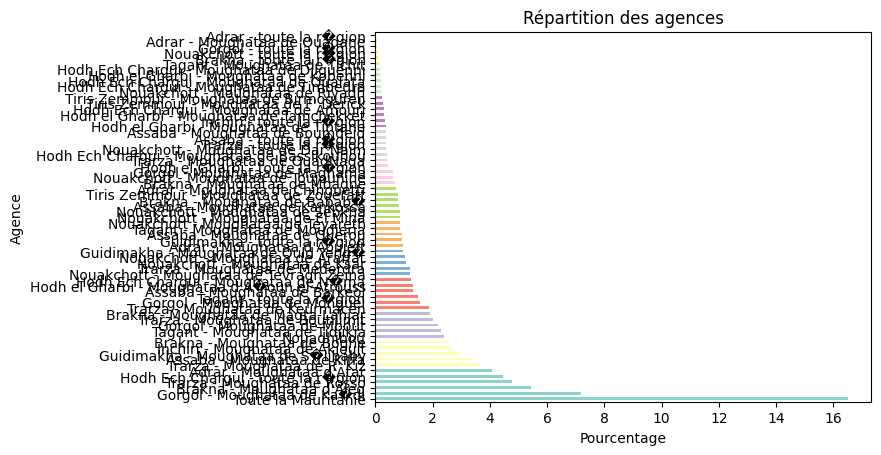

In [197]:
data = df['DEPNAISLIB'].value_counts(normalize=True).mul(100)

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

data.plot(kind='barh', color=colors)

plt.xlabel('Pourcentage')
plt.ylabel('Agence')
plt.title('Répartition des agences')

plt.show()